# Sistema de clasificación de imágenes

El conjunto de datos se compone de fotos de perros y gatos proporcionadas como un subconjunto de fotos de uno mucho más grande de 3 millones de fotos anotadas manualmente. Estos datos se obtuvieron a través de una colaboración entre Petfinder.com y Microsoft.

El conjunto de datos se usó originalmente como un CAPTCHA, es decir, una tarea que se cree que un humano encuentra trivial, pero que una máquina no puede resolver, que se usa en sitios web para distinguir entre usuarios humanos y bots. La tarea se denominó "Asirra". Cuando se presentó "Asirra", se mencionó "que los estudios de usuarios indican que los humanos pueden resolverlo el 99,6% de las veces en menos de 30 segundos". A menos que se produzca un gran avance en la visión artificial, esperamos que los ordenadores no tengan más de 1/54.000 posibilidades de resolverlo.

En el momento en que se publicó la competencia, el resultado de última generación se logró con un SVM y se describió en un artículo de 2007 con el título "Ataques de Machine Learning contra el CAPTCHA de Asirra" (PDF) que logró una precisión de clasificación del 80%. Fue este documento el que demostró que la tarea ya no era una tarea adecuada para un CAPTCHA poco después de que se propusiera la tarea.

In [15]:
import os
import random
import shutil
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix, classification_report
import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator

### Paso 1: Carga del conjunto de datos

In [4]:
# We explore the content
base_route = '/workspaces/inetke-machine-learning/data/raw/data-dogs-cats'

In [5]:
# Destination subfolders
train = os.path.join(base_route, 'train')
test  = os.path.join(base_route, 'test')

for split in ['train', 'test']:
    for cls in ['cats', 'dogs']:
        os.makedirs(os.path.join(base_route, split, cls), exist_ok=True)

cats = []
dogs = []

for file in os.listdir(base_route):
    f = file.lower()
    path = os.path.join(base_route, file)

    # Files only (ignore train and test folders)
    if os.path.isfile(path):
        if 'cat' in f:
            cats.append(file)
        elif 'dog' in f:
            dogs.append(file)

random.shuffle(cats)
random.shuffle(dogs)

# To split 80 / 20
cat_split = int(len(cats) * 0.8)
dog_split = int(len(dogs) * 0.8)

cats_train = cats[:cat_split]
cats_test  = cats[cat_split:]
dogs_train = dogs[:dog_split]
dogs_test  = dogs[dog_split:]

# Function for moving files
def move_files(files, target_dir):
    for file in files:
        shutil.copy(os.path.join(base_route, file),
                    os.path.join(target_dir, file))

move_files(cats_train, os.path.join(train, 'cats'))
move_files(dogs_train, os.path.join(train, 'dogs'))

move_files(cats_test, os.path.join(test, 'cats'))
move_files(dogs_test, os.path.join(test, 'dogs'))

In [6]:
f'Train → {len(cats_train)} cats, {len(dogs_train)} dogs'

'Train → 10000 cats, 10000 dogs'

In [7]:
f'Test  → {len(cats_test)} cats, {len(dogs_test)} dogs'

'Test  → 2500 cats, 2500 dogs'

### Paso 2: Visualiza la información de entrada

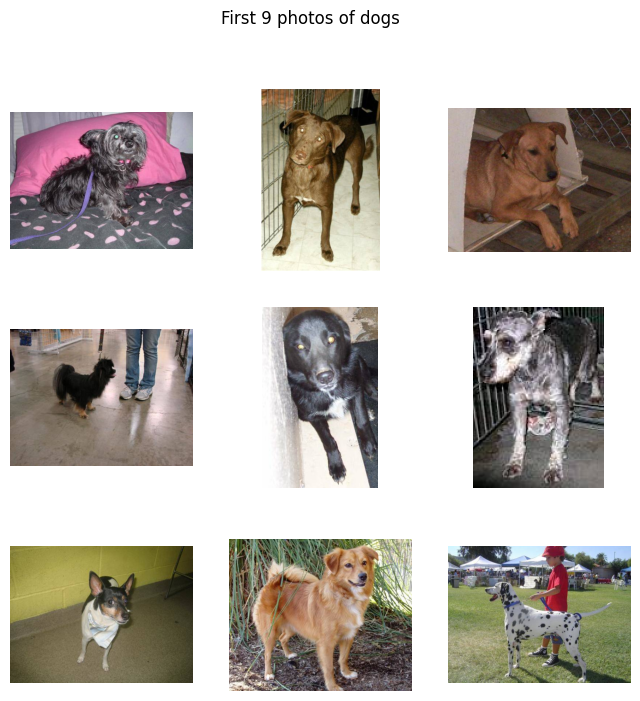

In [ ]:
dog_folder = os.path.join(train, 'dogs')

dog_files = sorted(os.listdir(dog_folder))[:9]

plt.figure(figsize=(8,8))
for i, f in enumerate(dog_files, 1):
    img = mpimg.imread(os.path.join(dog_folder, f))
    plt.subplot(3,3,i)
    plt.imshow(img)
    plt.axis('off')

plt.suptitle('First 9 photos of dogs')
plt.show()

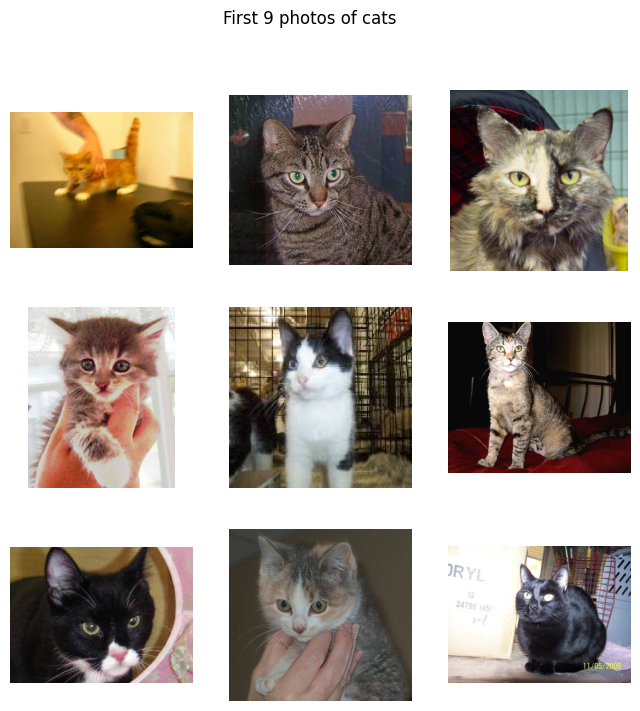

In [ ]:
cat_folder = os.path.join(train, 'cats')

cat_files = sorted(os.listdir(cat_folder))[:9]

plt.figure(figsize=(8,8))
for i, f in enumerate(cat_files, 1):
    img = mpimg.imread(os.path.join(cat_folder, f))
    plt.subplot(3,3,i)
    plt.imshow(img)
    plt.axis('off')

plt.suptitle('First 9 photos of cats')
plt.show()

#### Observaciones:
Se visualizaron las primeras 9 imágenes de perros y gatos para inspeccionar el dataset.   
Se observó que las imágenes tienen distintos tamaños y posiciones del animal, por lo que se decidió redimensionarlas a un tamaño fijo antes del entrenamiento.

In [17]:
IMG_SIZE = (200, 200)
BATCH_SIZE = 32

tr_gen = ImageDataGenerator(rescale=1./255,
                            rotation_range=15,
                            zoom_range=0.1,
                            width_shift_range=0.1,
                            height_shift_range=0.1,
                            horizontal_flip=True)

ts_gen = ImageDataGenerator(rescale=1./255)

In [ ]:
trdata = tr_gen.flow_from_directory(train,
                                    target_size=IMG_SIZE,
                                    batch_size=BATCH_SIZE,
                                    class_mode="categorical",
                                    shuffle=True)

tsdata = ts_gen.flow_from_directory(test,
                                    target_size=IMG_SIZE,
                                    batch_size=BATCH_SIZE,
                                    class_mode="categorical",
                                    shuffle=False)

print("Clases detectadas:", trdata.class_indices)

Found 24797 images belonging to 2 classes.
Found 12189 images belonging to 2 classes.
Clases detectadas: {'cats': 0, 'dogs': 1}


In [19]:
x_batch, y_batch = next(trdata)
print("Batch X:", x_batch.shape)  # (batch, 224,224,3) o (batch,200,200,3)
print("Batch y:", y_batch.shape)  # (batch, 2)

Batch X: (32, 200, 200, 3)
Batch y: (32, 2)
